Udemy for pyTorch

In [2]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
x = torch.linspace(0,799,800)

In [4]:
π = np.pi

In [5]:
# Period of oscillation
T = 40

In [6]:
y = torch.sin(x*2*π/T)

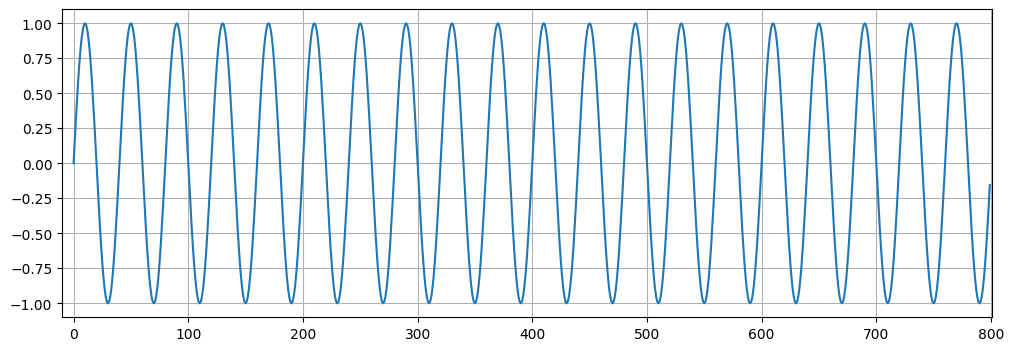

In [7]:
plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(y.numpy());

In [8]:
test_size = T
train_set = y[:-test_size]
test_set = y[-test_size:]

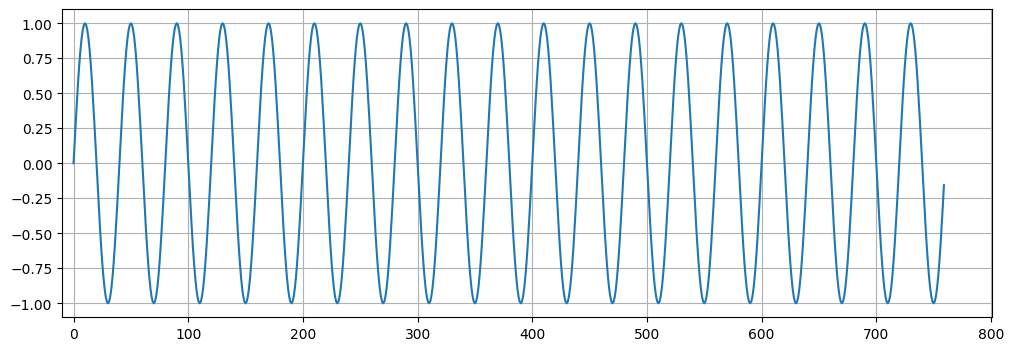

In [10]:
plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(train_set.numpy());

In [11]:
def input_data(seq,ws):

    out = []
    L = len(seq)

    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))

    return out

In [12]:
window_size = T

train_data = input_data(train_set,window_size)

In [13]:
len(train_data)

720

In [14]:
train_data[0]

(tensor([ 0.0000e+00,  1.5643e-01,  3.0902e-01,  4.5399e-01,  5.8779e-01,
          7.0711e-01,  8.0902e-01,  8.9101e-01,  9.5106e-01,  9.8769e-01,
          1.0000e+00,  9.8769e-01,  9.5106e-01,  8.9101e-01,  8.0902e-01,
          7.0711e-01,  5.8779e-01,  4.5399e-01,  3.0902e-01,  1.5643e-01,
         -8.7423e-08, -1.5643e-01, -3.0902e-01, -4.5399e-01, -5.8779e-01,
         -7.0711e-01, -8.0902e-01, -8.9101e-01, -9.5106e-01, -9.8769e-01,
         -1.0000e+00, -9.8769e-01, -9.5106e-01, -8.9101e-01, -8.0902e-01,
         -7.0711e-01, -5.8779e-01, -4.5399e-01, -3.0902e-01, -1.5643e-01]),
 tensor([1.7485e-07]))

In [16]:
train_data[1]

(tensor([ 1.5643e-01,  3.0902e-01,  4.5399e-01,  5.8779e-01,  7.0711e-01,
          8.0902e-01,  8.9101e-01,  9.5106e-01,  9.8769e-01,  1.0000e+00,
          9.8769e-01,  9.5106e-01,  8.9101e-01,  8.0902e-01,  7.0711e-01,
          5.8779e-01,  4.5399e-01,  3.0902e-01,  1.5643e-01, -8.7423e-08,
         -1.5643e-01, -3.0902e-01, -4.5399e-01, -5.8779e-01, -7.0711e-01,
         -8.0902e-01, -8.9101e-01, -9.5106e-01, -9.8769e-01, -1.0000e+00,
         -9.8769e-01, -9.5106e-01, -8.9101e-01, -8.0902e-01, -7.0711e-01,
         -5.8779e-01, -4.5399e-01, -3.0902e-01, -1.5643e-01,  1.7485e-07]),
 tensor([0.1564]))

In [17]:
class LSTMmodel(nn.Module):

    def __init__(self, input_size=1, hidden_size=50, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(input_size,hidden_size)

        self.linear = nn.Linear(hidden_size,out_size)

        self.hidden = (torch.zeros(1,1,hidden_size),
                       torch.zeros(1,1,hidden_size))

    def forward(self,seq):
        lstm_out, self.hidden = self.lstm(
            seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]


In [18]:
model = LSTMmodel()

In [19]:
model

LSTMmodel(
  (lstm): LSTM(1, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [20]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [21]:
for p in model.parameters():
    print(p.numel())

200
10000
200
200
50
1


Epoch:  1 Loss: 0.07740534
Loss on test predictions: 0.5864370465278625


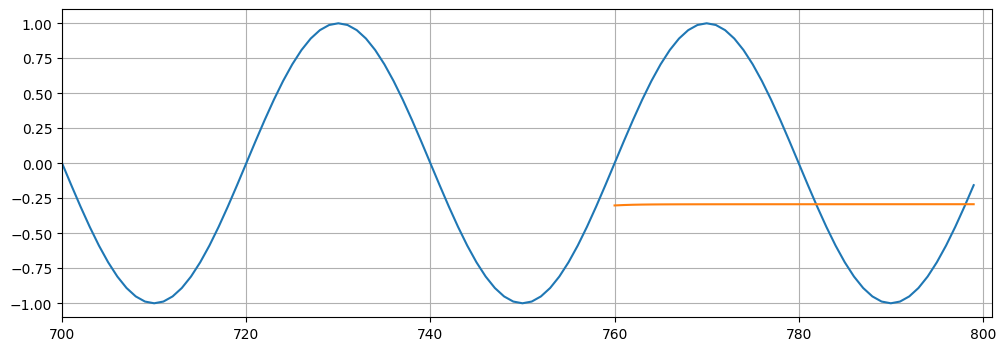

Epoch:  2 Loss: 0.04916451
Loss on test predictions: 0.536962628364563


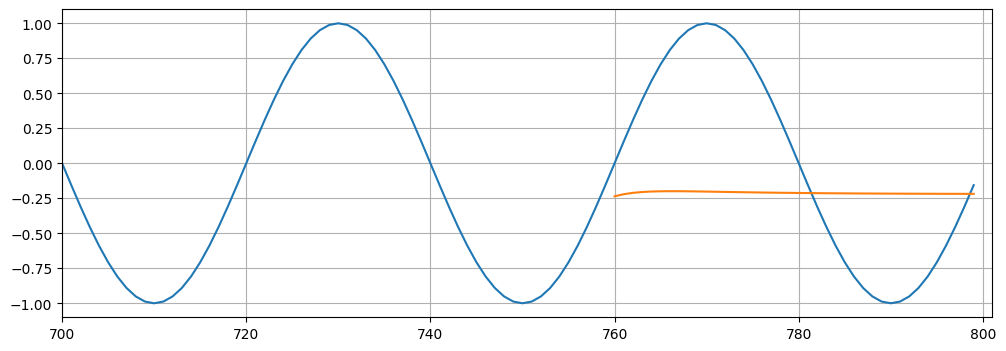

Epoch:  3 Loss: 0.02049106
Loss on test predictions: 0.4403969645500183


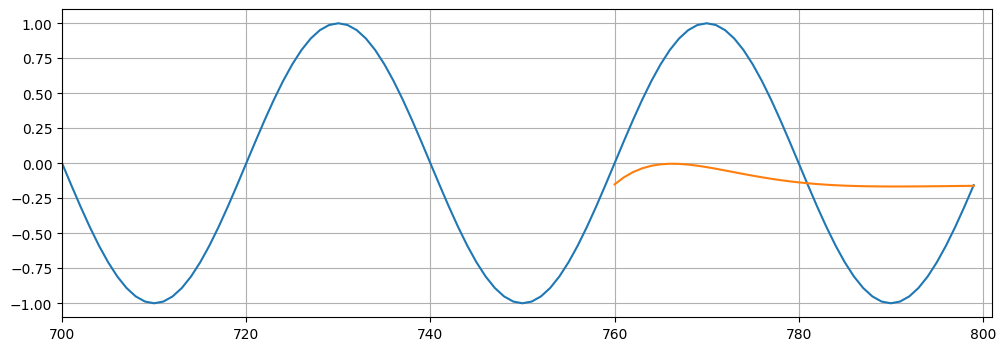

Epoch:  4 Loss: 0.00203106
Loss on test predictions: 0.1540425568819046


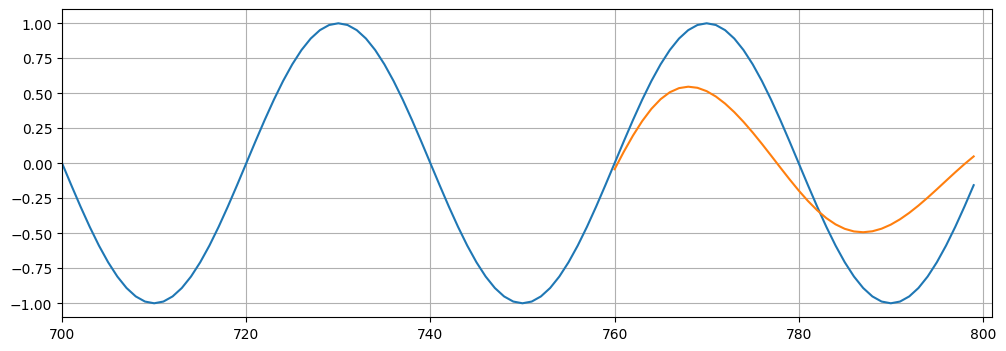

Epoch:  5 Loss: 0.00007729
Loss on test predictions: 0.008117012679576874


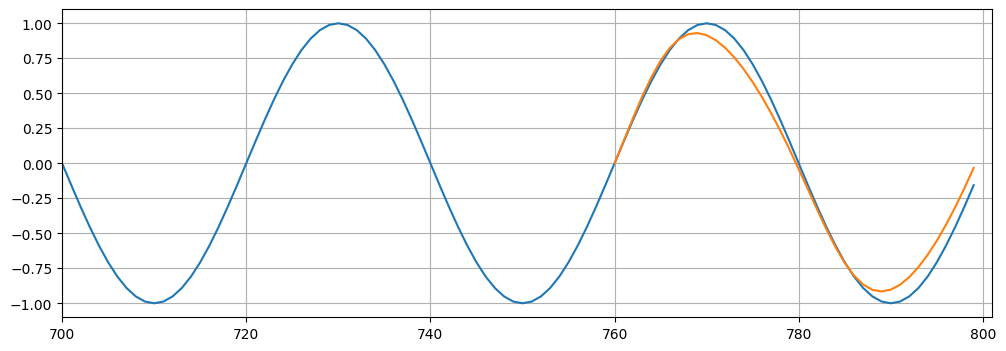

Epoch:  6 Loss: 0.00002208
Loss on test predictions: 0.002091520931571722


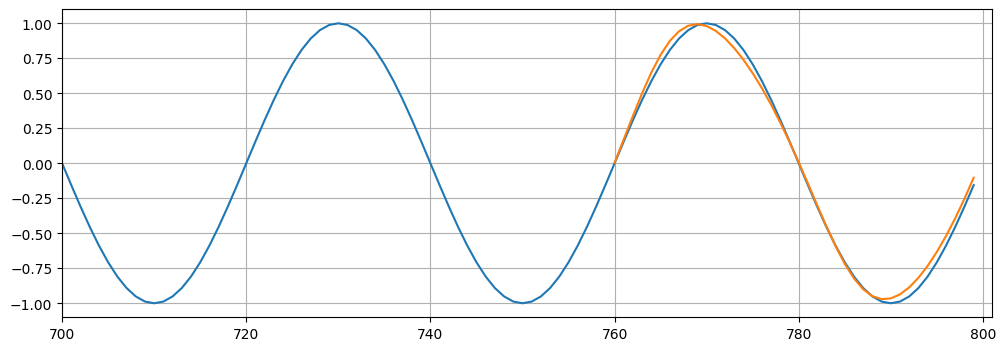

Epoch:  7 Loss: 0.00002169
Loss on test predictions: 0.0018951145466417074


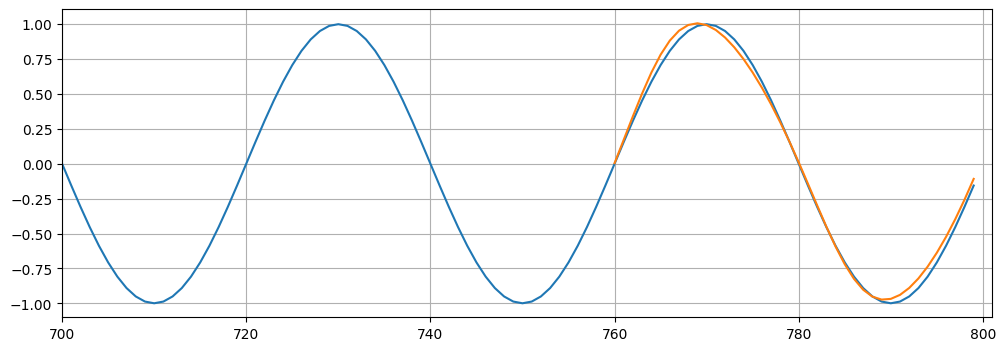

Epoch:  8 Loss: 0.00002435
Loss on test predictions: 0.00193023681640625


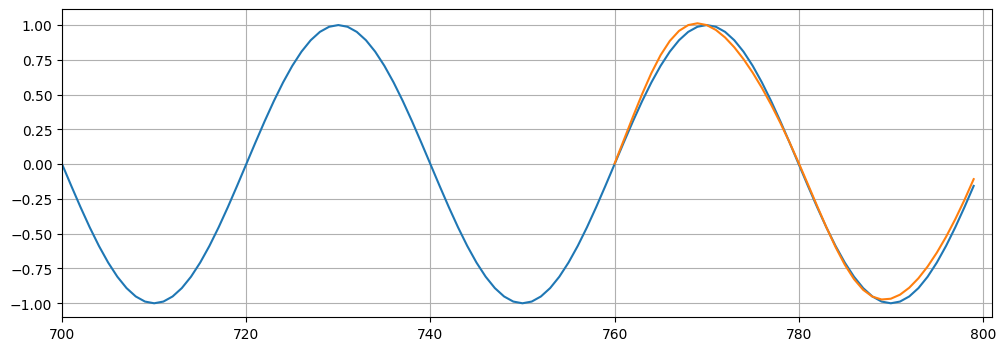

Epoch:  9 Loss: 0.00002697
Loss on test predictions: 0.001969673437997699


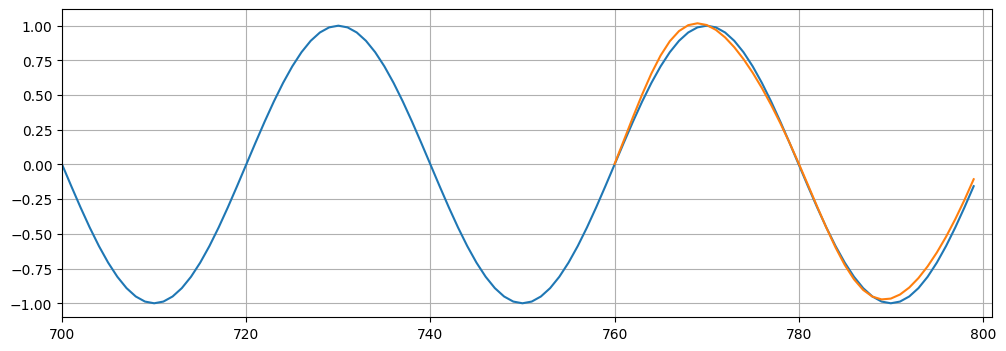

Epoch: 10 Loss: 0.00002925
Loss on test predictions: 0.0019948489498347044


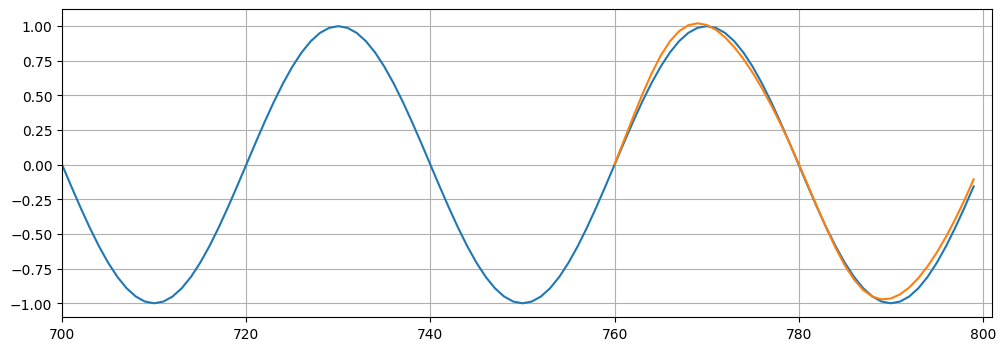

Epoch: 11 Loss: 0.00003116
Loss on test predictions: 0.002005451126024127


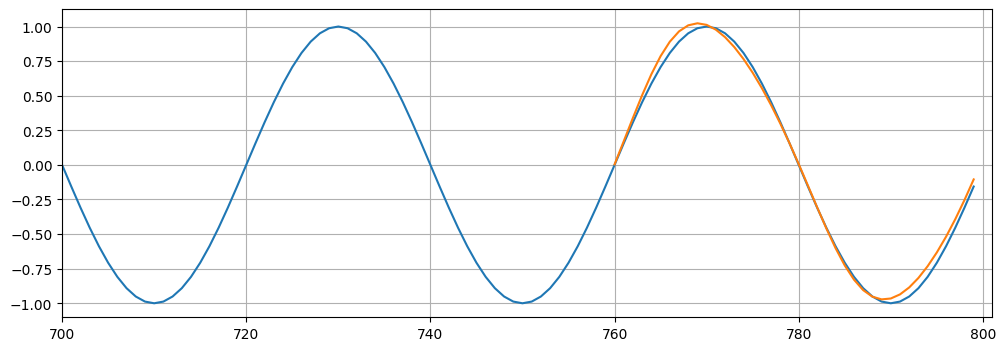

Epoch: 12 Loss: 0.00003272
Loss on test predictions: 0.0020034988410770893


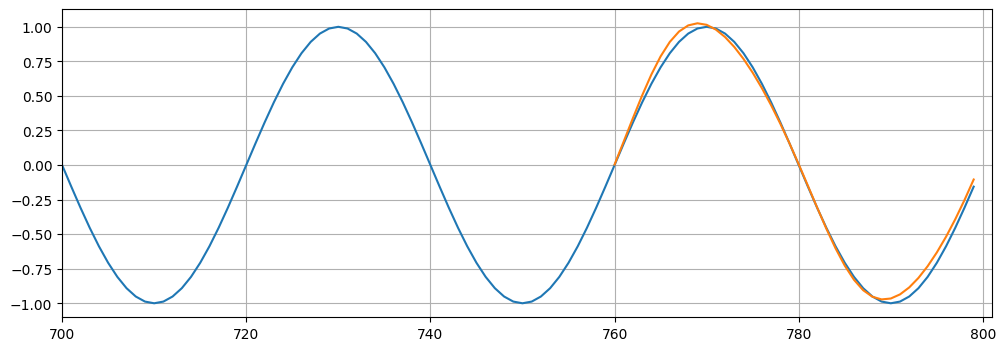

Epoch: 13 Loss: 0.00003396
Loss on test predictions: 0.0019916717428714037


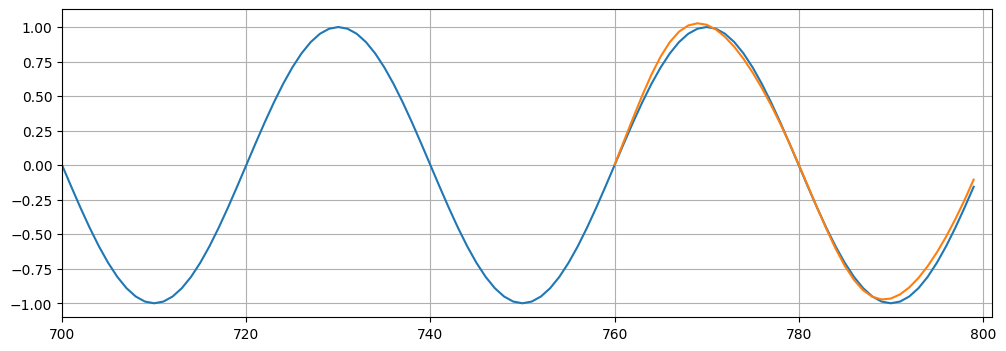

Epoch: 14 Loss: 0.00003491
Loss on test predictions: 0.00197224086150527


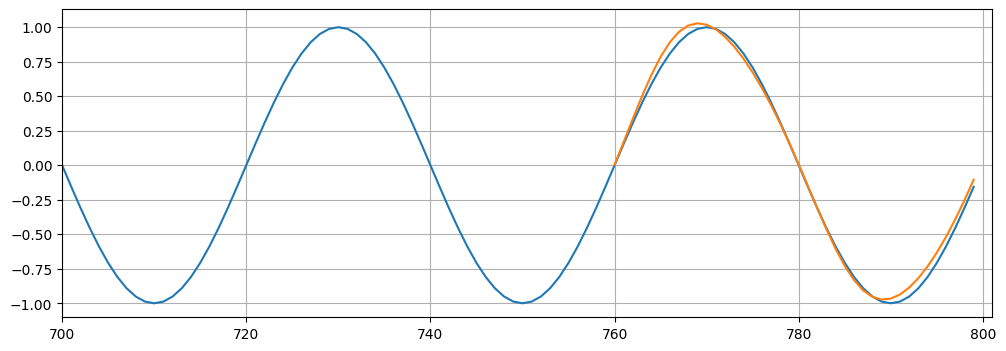

Epoch: 15 Loss: 0.00003560
Loss on test predictions: 0.0019472409039735794


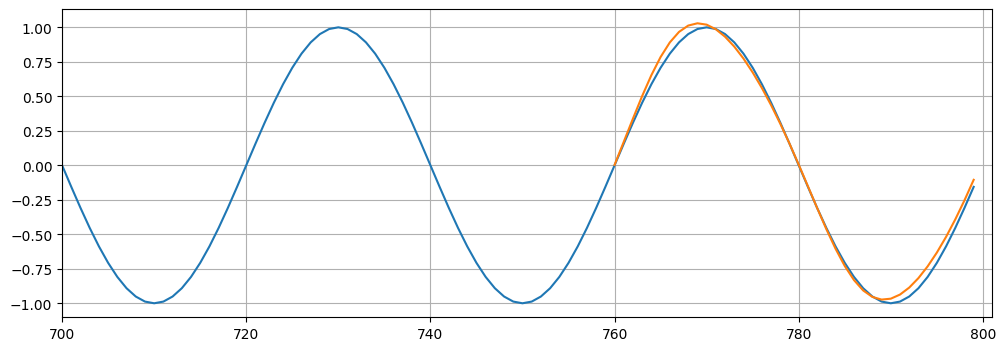

In [22]:
epochs = 15
future = T

for i in range(epochs):

    # tuple-unpack the train_data set
    for seq, y_train in train_data:

        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))

        y_pred = model(seq)

        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

    # print training result
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')

    # MAKE PREDICTIONS
    # start with a list of the last 10 training records
    preds = train_set[-window_size:].tolist()

    for f in range(future):
        seq = torch.FloatTensor(preds[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),
                            torch.zeros(1,1,model.hidden_size))
            preds.append(model(seq).item())

    loss = criterion(torch.tensor(preds[-window_size:]),y[760:])
    print(f'Loss on test predictions: {loss}')

    # Plot from point 700 to the end
    plt.figure(figsize=(12,4))
    plt.xlim(700,801)
    plt.grid(True)
    plt.plot(y.numpy())
    plt.plot(range(760,800),preds[window_size:])
    plt.show()

In [23]:
epochs = 20
window_size = 40
future = 40

all_data = input_data(y,window_size)

In [24]:
import time
start_time = time.time()

for i in range(epochs):

    # tuple-unpack the train_data set
    for seq, y_train in all_data:

        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))

        y_pred = model(seq)

        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

    # print training result
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')

total_time = time.time() - start_time
print(total_time/60)

Epoch:  1 Loss: 0.00003609
Epoch:  2 Loss: 0.00003636
Epoch:  3 Loss: 0.00003644
Epoch:  4 Loss: 0.00003637
Epoch:  5 Loss: 0.00003617
Epoch:  6 Loss: 0.00003587
Epoch:  7 Loss: 0.00003548
Epoch:  8 Loss: 0.00003503
Epoch:  9 Loss: 0.00003452
Epoch: 10 Loss: 0.00003398
Epoch: 11 Loss: 0.00003340
Epoch: 12 Loss: 0.00003281
Epoch: 13 Loss: 0.00003220
Epoch: 14 Loss: 0.00003158
Epoch: 15 Loss: 0.00003095
Epoch: 16 Loss: 0.00003033
Epoch: 17 Loss: 0.00002971
Epoch: 18 Loss: 0.00002909
Epoch: 19 Loss: 0.00002849
Epoch: 20 Loss: 0.00002789
0.24669362703959147


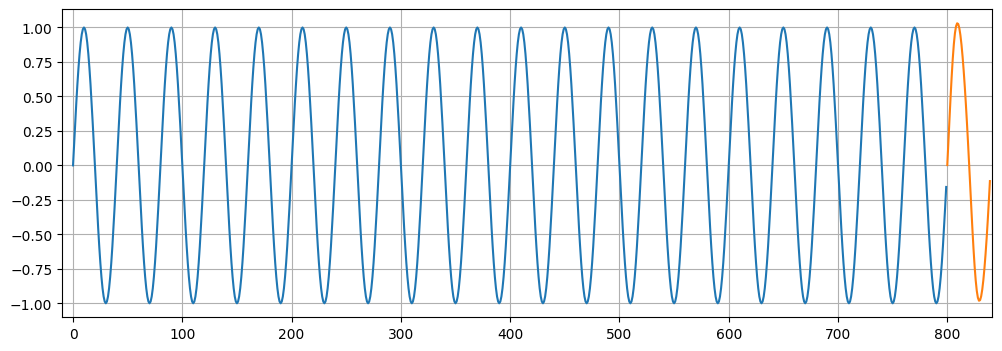

In [25]:
preds = y[-window_size:].tolist()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        # Reset the hidden parameters
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        preds.append(model(seq).item())

plt.figure(figsize=(12,4))
plt.xlim(-10,841)
plt.grid(True)
plt.plot(y.numpy())
plt.plot(range(800,800+future),preds[window_size:])
plt.show()